# import credentials and data


In [2]:
import pandas as pd
import numpy as np

In [3]:
creds = '{"username":"alaricmcgrath","key":"113cbb1e4b455265e9253ee62398f40e"}'
from pathlib import Path

# Set up Kaggle credentials
cred_path = Path('~/.kaggle/kaggle.json').expanduser()
if not cred_path.exists():
    cred_path.parent.mkdir(exist_ok=True)
    cred_path.write_text(creds)
    cred_path.chmod(0o600)

# Define the path for the dataset
path = Path('breast-cancer-wisconsin')
#if not path.exists():
import zipfile, kaggle

    # Download the dataset using Kaggle API
kaggle.api.dataset_download_files('uciml/breast-cancer-wisconsin-data', path=path, unzip=True)



Dataset URL: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data


# data exploration and preprossesing

In [4]:
df = pd.read_csv(path/'data.csv')

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


remove unecessary coulmns

In [5]:
# Assuming your DataFrame is named df
columns_to_drop = ['id', 'Unnamed: 32']

# Drop the specified columns
df_cleaned = df.drop(columns=columns_to_drop)

# Alternatively, you can use the inplace parameter to modify the DataFrame in place:
# df.drop(columns=columns_to_drop, inplace=True)
df_cleaned.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


get dummy for diagnosis column

In [6]:
df = pd.get_dummies(df_cleaned, columns=["diagnosis"])
df.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis_B,diagnosis_M
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,False,True
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,False,True
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,False,True
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,False,True
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,False,True


normalize data

In [7]:
from sklearn.preprocessing import MinMaxScaler

# Create a MinMaxScaler object
min_max_scaler = MinMaxScaler()

# Apply normalization to the entire DataFrame
df_normalized = pd.DataFrame(min_max_scaler.fit_transform(df), columns=df.columns)
df_normalized.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis_B,diagnosis_M
0,0.521037,0.022658,0.545989,0.363733,0.593753,0.792037,0.703140,0.731113,0.686364,0.605518,...,0.668310,0.450698,0.601136,0.619292,0.568610,0.912027,0.598462,0.418864,0.0,1.0
1,0.643144,0.272574,0.615783,0.501591,0.289880,0.181768,0.203608,0.348757,0.379798,0.141323,...,0.539818,0.435214,0.347553,0.154563,0.192971,0.639175,0.233590,0.222878,0.0,1.0
2,0.601496,0.390260,0.595743,0.449417,0.514309,0.431017,0.462512,0.635686,0.509596,0.211247,...,0.508442,0.374508,0.483590,0.385375,0.359744,0.835052,0.403706,0.213433,0.0,1.0
3,0.210090,0.360839,0.233501,0.102906,0.811321,0.811361,0.565604,0.522863,0.776263,1.000000,...,0.241347,0.094008,0.915472,0.814012,0.548642,0.884880,1.000000,0.773711,0.0,1.0
4,0.629893,0.156578,0.630986,0.489290,0.430351,0.347893,0.463918,0.518390,0.378283,0.186816,...,0.506948,0.341575,0.437364,0.172415,0.319489,0.558419,0.157500,0.142595,0.0,1.0


remove unecessary coulmn that was created when the dummy was made

In [8]:
columns_to_drop = ['diagnosis_B']

# Drop the specified columns
df = df_normalized.drop(columns=columns_to_drop)

# advanced data exploration

use seaborn to show distribution of malignant and benign

/tmp/ipykernel_25538/1261199139.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis_M', data=df, palette='viridis')


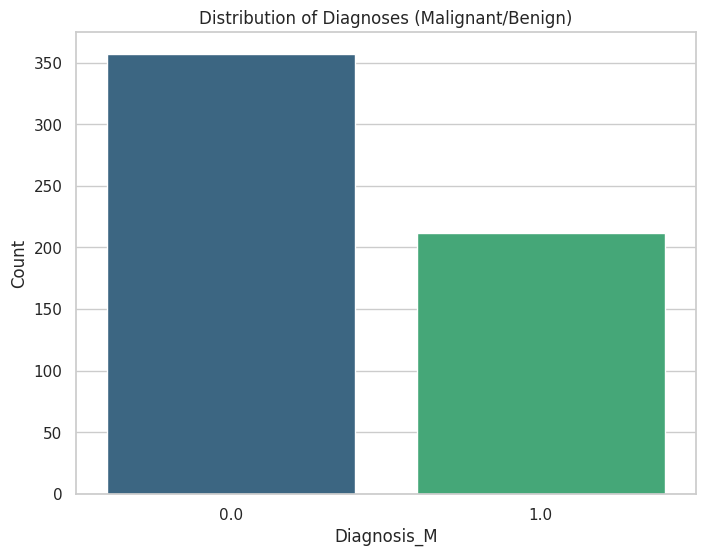

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'diagnosis_M' is the column containing Malignant/Benign labels
sns.set(style="whitegrid")
plt.figure(figsize=(8, 6))

# Use countplot to visualize the distribution
sns.countplot(x='diagnosis_M', data=df, palette='viridis')

# Set labels and title
plt.xlabel('Diagnosis_M')
plt.ylabel('Count')
plt.title('Distribution of Diagnoses (Malignant/Benign)')

# Show the plot
plt.show()


create heatmap to show correlation matrix of the features

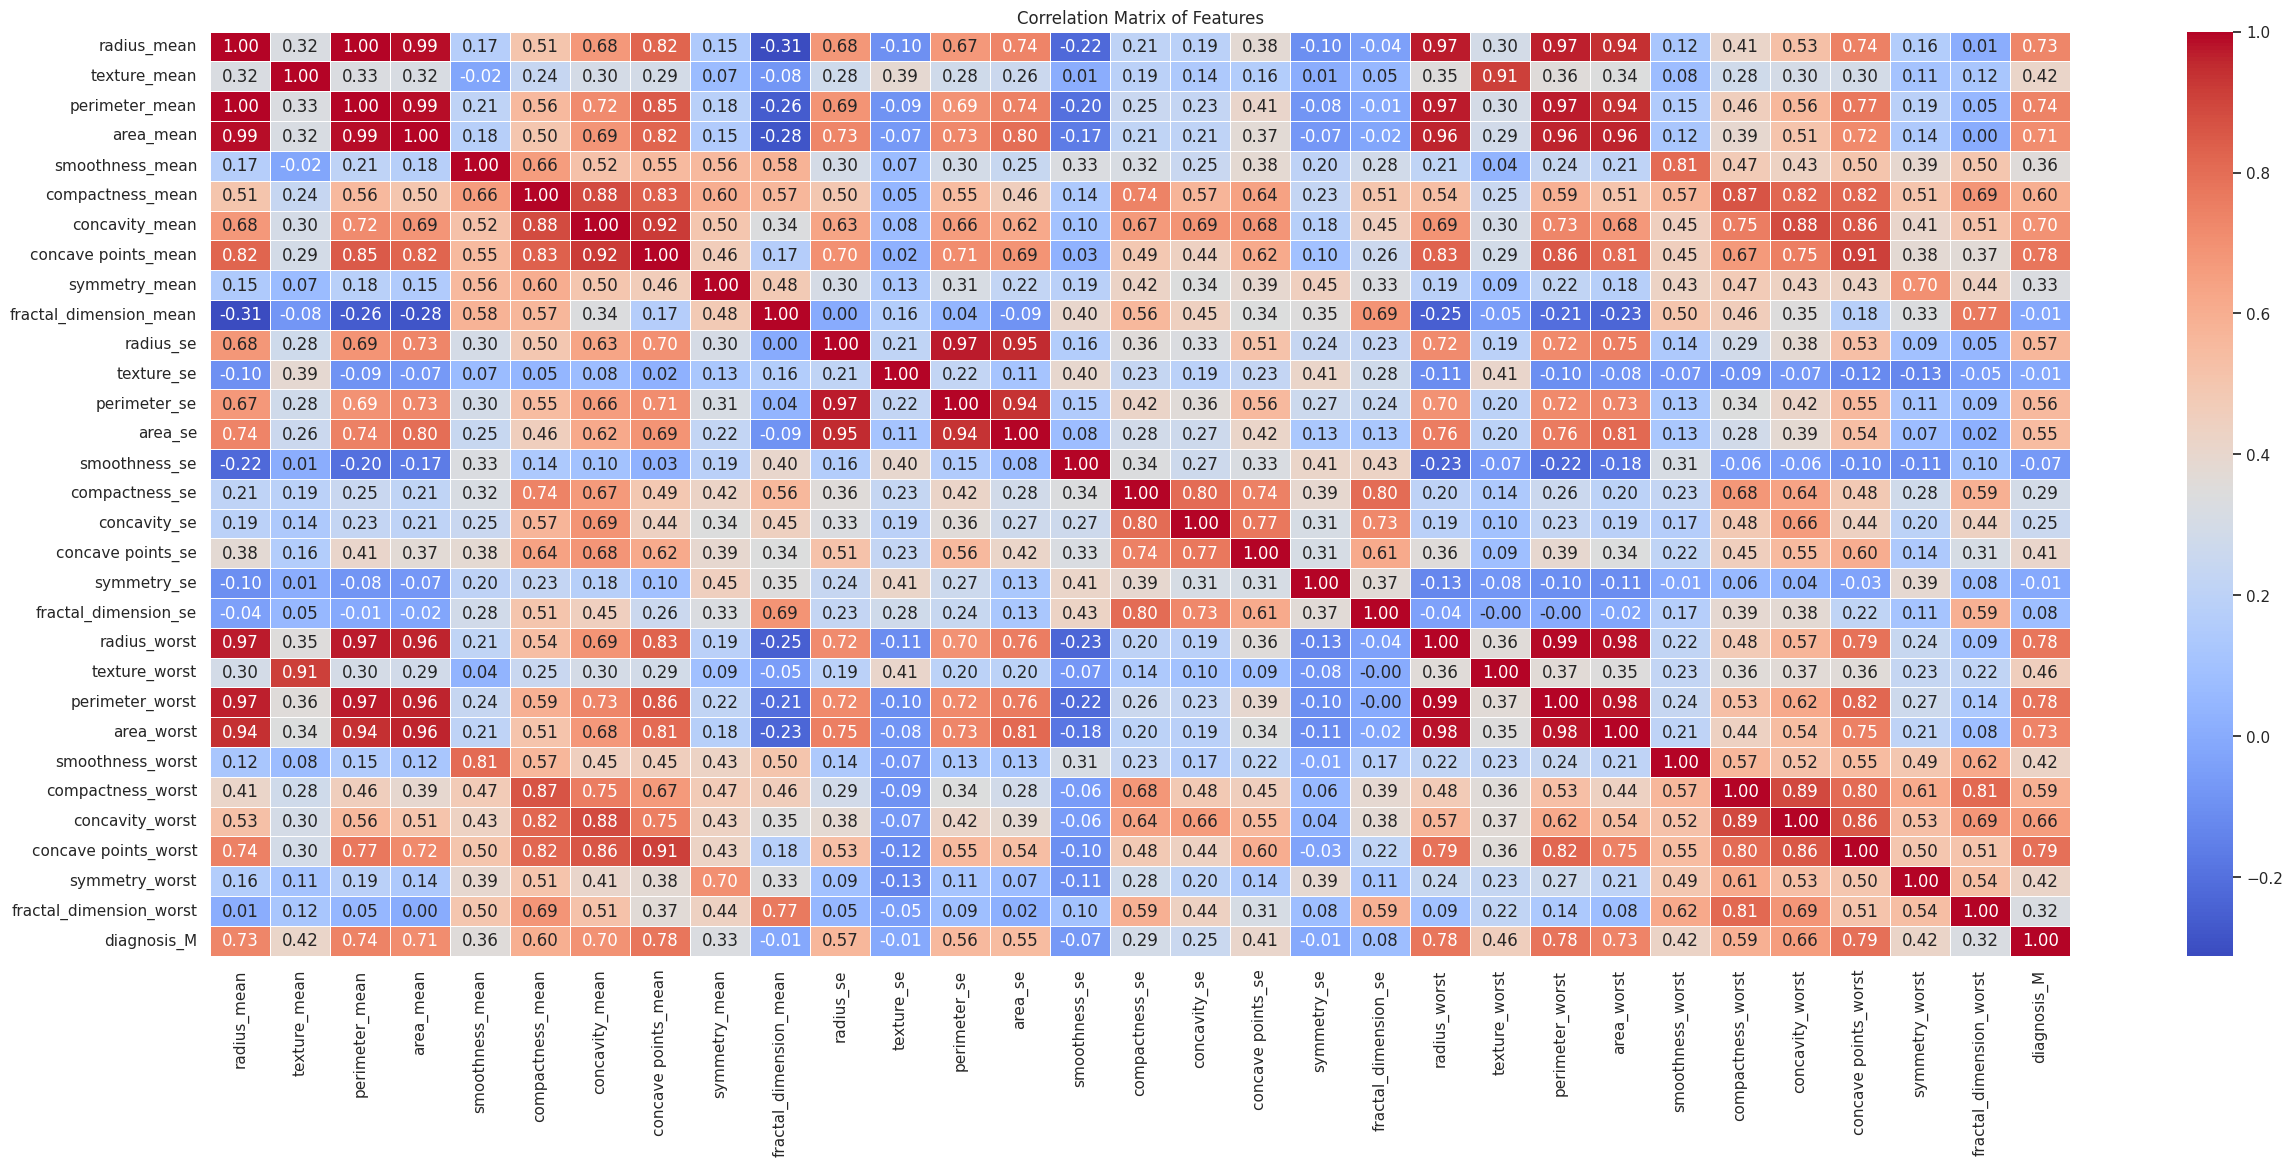

In [10]:


# Calculate the correlation matrix
correlation_matrix = df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(30, 12))

# Create a heatmap using Seaborn
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)

# Set title
plt.title('Correlation Matrix of Features')

# Show the plot
plt.show()


# feature selection techniques

remove correlated columns, I decided to do it manually.

In [11]:
# Step 1: Calculate the correlation matrix
#correlation_matrix = df.corr()

# Step 2: Create a set to hold the names of correlated columns
#correlated_columns = set()

# Step 3: Iterate through the correlation matrix and identify highly correlated features
#for i in range(len(correlation_matrix.columns)):
    #for j in range(i):
        #if abs(correlation_matrix.iloc[i, j]) > 0.8:  # You can adjust the correlation threshold as needed
            #colname = correlation_matrix.columns[i]
            #correlated_columns.add(colname)

# Step 4: Drop the highly correlated columns from the DataFrame
#df = df.drop(columns=correlated_columns)

# Optional: Print the list of dropped columns
#print("Dropped Columns:", correlated_columns)

# Optional: Print the DataFrame with selected features
#df.head()


In [12]:
columns_to_drop = ['perimeter_mean' , 'area_mean' , 'perimeter_worst' , 'radius_worst' , 'perimeter_se']

# Drop the specified columns
df = df.drop(columns=columns_to_drop)
df.head()

,radius_mean,texture_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,...,fractal_dimension_se,texture_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis_M
0,0.521037,0.022658,0.593753,0.792037,0.703140,0.731113,0.686364,0.605518,0.356147,0.120469,...,0.183042,0.141525,0.450698,0.601136,0.619292,0.568610,0.912027,0.598462,0.418864,1.0
1,0.643144,0.272574,0.289880,0.181768,0.203608,0.348757,0.379798,0.141323,0.156437,0.082589,...,0.091110,0.303571,0.435214,0.347553,0.154563,0.192971,0.639175,0.233590,0.222878,1.0
2,0.601496,0.390260,0.514309,0.431017,0.462512,0.635686,0.509596,0.211247,0.229622,0.094303,...,0.127006,0.360075,0.374508,0.483590,0.385375,0.359744,0.835052,0.403706,0.213433,1.0
3,0.210090,0.360839,0.811321,0.811361,0.565604,0.522863,0.776263,1.000000,0.139091,0.175875,...,0.287205,0.385928,0.094008,0.915472,0.814012,0.548642,0.884880,1.000000,0.773711,1.0
4,0.629893,0.156578,0.430351,0.347893,0.463918,0.518390,0.378283,0.186816,0.233822,0.093065,...,0.145800,0.123934,0.341575,0.437364,0.172415,0.319489,0.558419,0.157500,0.142595,1.0


use RandomForestClassifier to understand importance of specifc features

Feature Importance:
                    Feature  Importance
18               area_worst    0.200188
22     concave points_worst    0.191420
5       concave points_mean    0.133902
10                  area_se    0.087009
0               radius_mean    0.070290
4            concavity_mean    0.063682
21          concavity_worst    0.046283
8                 radius_se    0.032733
20        compactness_worst    0.031446
1              texture_mean    0.020773
17            texture_worst    0.018709
19         smoothness_worst    0.013002
23           symmetry_worst    0.010598
3          compactness_mean    0.010312
24  fractal_dimension_worst    0.009157
16     fractal_dimension_se    0.008575
14        concave points_se    0.008120
7    fractal_dimension_mean    0.007803
2           smoothness_mean    0.007166
12           compactness_se    0.005100
9                texture_se    0.005087
13             concavity_se    0.005073
15              symmetry_se    0.005060
11            smooth

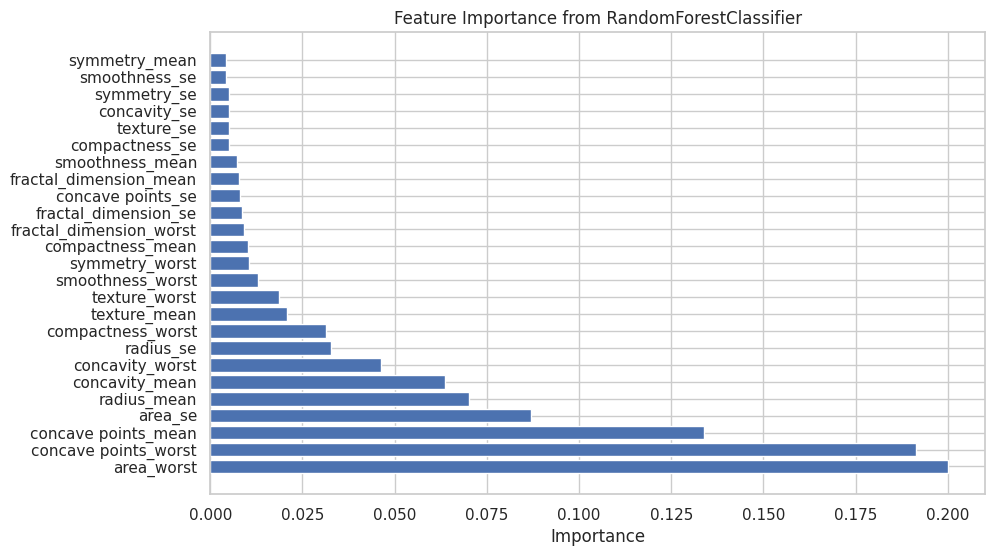

In [13]:
from sklearn.ensemble import RandomForestClassifier


# Step 1: Separate features (X) and target variable (y)
X = df.drop(columns=['diagnosis_M'])
y = df['diagnosis_M']

# Step 2: Initialize a RandomForestClassifier
rf_classifier = RandomForestClassifier()

# Step 3: Fit the model to your data
rf_classifier.fit(X, y)

# Step 4: Get feature importances
feature_importances = rf_classifier.feature_importances_

# Step 5: Create a DataFrame to display feature importances
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})

# Step 6: Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Optional: Print the feature importance DataFrame
print("Feature Importance:")
print(feature_importance_df)

# Optional: Plot the feature importances
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance from RandomForestClassifier')
plt.show()


# Model Development, Evaluation, and Optimization

In [14]:
from sklearn.model_selection import train_test_split

#you want to split 80% for training and 20% for testing
X = df.drop('diagnosis_M', axis=1)  # Features
y = df['diagnosis_M']  # Target variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Now X_train and y_train contain the training data, and X_test and y_test contain the testing data


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Create a RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the classifier using the training data
clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = clf.predict(X_test)



Accuracy: 0.96


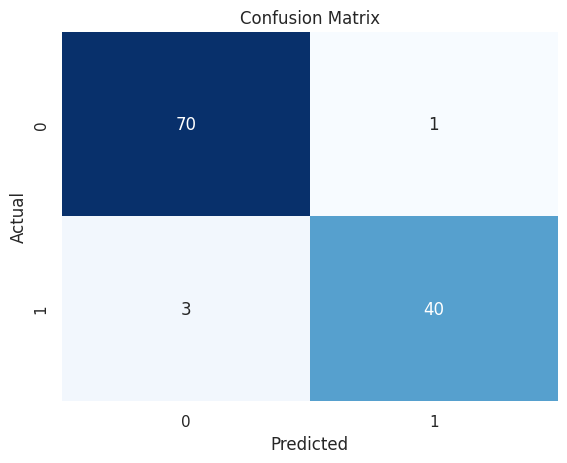

In [16]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Make predictions on the test set
y_pred = clf.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Create a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [17]:
from sklearn.model_selection import cross_val_score


# Create a RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100, min_samples_split=2, random_state=42)

# Perform cross-validation
cv_scores = cross_val_score(clf, X, y, cv=5)  # Assuming 5-fold cross-validation

# Print the cross-validation scores
print("Cross-Validation Scores:", cv_scores)

# Print the mean and standard deviation of the scores
print(f"Mean Accuracy: {np.mean(cv_scores):.2f}")
print(f"Standard Deviation: {np.std(cv_scores):.2f}")


Cross-Validation Scores: [0.93859649 0.95614035 0.99122807 0.96491228 0.98230088]
Mean Accuracy: 0.97
Standard Deviation: 0.02


In [18]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# Create a RandomForestClassifier
clf = RandomForestClassifier(random_state=42)

# Use GridSearchCV to find the best combination of hyperparameters
grid_search = GridSearchCV(clf, param_grid, cv=5)
grid_search.fit(X, y)

# Get the best parameters
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)

# Get the best model
best_model = grid_search.best_estimator_


Best Hyperparameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


In [19]:
from sklearn.feature_selection import RFE

# Create a RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Use RFE for feature selection
rfe = RFE(clf, n_features_to_select=10)  # Adjust the number of features as needed
X_selected = rfe.fit_transform(X, y)


In [20]:
# Retrain the model with the best hyperparameters
optimized_clf = RandomForestClassifier(**best_params, random_state=42)
optimized_clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred_optimized = optimized_clf.predict(X_test)

# Evaluate the optimized model
accuracy_optimized = accuracy_score(y_test, y_pred_optimized)
print(f"Optimized Model Accuracy: {accuracy_optimized:.2f}")


Optimized Model Accuracy: 0.96
